# Libraries

In [900]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [901]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240605 - Ag60 GDE_0.3 M K2SO4_pH2

16-Aug-26  11:24 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
29-Jul-26  05:01 AM    <DIR>          .ipynb_checkpoints
29-Jul-26  11:29 AM           186,066 0p3M_pH2 K2SO4_20240607_1301_1min - Copy.xlsx
29-Jul-26  11:30 AM            66,274 0p3M_pH2 K2SO4_20240607_1301_1min.xlsx
07-Jun-24  03:01 PM            21,844 0p3M_pH2 K2SO4_20240607_1301_5min.xlsx
07-Jun-24  03:01 PM           670,811 0p3M_pH2 K2SO4_20240607_1301_Line_1.csv
25-Jul-25  09:26 PM           903,635 20240605 - Ag60 GDE_0.3 M K2SO4_pH2.ipynb
29-Jul-26  05:53 AM           687,413 20240605 - Ag60 GDE_0.3 M K2SO4_pH2-CORRECTED - Copy.ipynb
16-Aug-26  11:24 PM           898,650 20240605 - Ag60 GDE_0.3 M K2SO4_pH2-CORRECTED.ipynb
16-Aug-26  11:24 PM               598 20240605_0.3 M K2SO4_pH2_Energy Consumption.csv
16-Aug-26

# Load Data

In [902]:
Book = "Book_20240605 - Ag60 GDE_0.3 M K2SO4_pH2.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,59.277917,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-05 17:42:00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
1,Ag60 GDE in PTFE holder,60,61.242460,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:03:04,0.351111,1.359127,...,0.013241,0.000730,0.985598,0.000418,1.003078,0.055291,NaN,1.058369,0.000740,NaN
2,Ag60 GDE in PTFE holder,60,60.957708,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:25:36,0.726667,1.353346,...,0.013278,0.000231,0.986103,0.000378,1.001195,0.017423,NaN,1.018618,0.000234,100.528989
3,Ag60 GDE in PTFE holder,60,60.738387,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:48:06,1.101667,1.359606,...,0.013345,0.000198,0.986059,0.000389,1.002589,0.014863,NaN,1.017453,0.000201,NaN
4,Ag60 GDE in PTFE holder,60,60.688119,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 19:10:36,1.476667,1.357080,...,0.013332,0.000172,0.986107,0.000378,1.000821,0.012917,NaN,1.013738,0.000174,100.392455
5,Ag60 GDE in PTFE holder,60,60.732710,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 19:33:07,1.851944,1.358233,...,0.013332,0.000173,0.986104,0.000379,1.001570,0.013020,NaN,1.014590,0.000176,NaN
6,Ag60 GDE in PTFE holder,60,61.529210,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 19:55:39,2.227500,1.973462,...,0.019273,0.010799,0.968343,0.000371,0.581298,0.325704,NaN,0.907002,0.011029,100.259385
7,Ag60 GDE in PTFE holder,60,61.289701,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 20:28:40,2.777778,2.091754,...,0.020440,0.013083,0.966086,0.000380,0.614085,0.393064,NaN,1.007150,0.013361,NaN
8,Ag60 GDE in PTFE holder,60,61.218076,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 20:51:11,3.153056,2.157189,...,0.021071,0.012192,0.966350,0.000376,0.632309,0.365872,NaN,0.998181,0.012460,100.181206
9,Ag60 GDE in PTFE holder,60,61.038255,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 21:13:41,3.528056,2.156862,...,0.020970,0.012490,0.964976,0.000365,0.627427,0.373712,NaN,1.001139,0.012778,NaN


In [903]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
47,Ag60 GDE in PTFE holder,60,71.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-3.1,2024-06-06 09:03:40,15.36,15.518663,...,0.146257,0.702069,0.001422,0.453677,0.444910,NaN,0.898586,0.172406,NaN,71.25
48,Ag60 GDE in PTFE holder,60,70.64,0.3 M K2SO4,Deionized wated,CCM-CEM,-3.1,2024-06-06 09:18:41,15.61,15.661130,...,0.145572,0.701393,0.001437,0.453746,0.439037,NaN,0.892783,0.171875,88.1653,70.64
49,Ag60 GDE in PTFE holder,60,70.88,0.3 M K2SO4,Deionized wated,CCM-CEM,-3.1,2024-06-06 09:33:42,15.86,15.755493,...,0.145574,0.701534,0.001402,0.458417,0.440556,NaN,0.898973,0.171849,NaN,70.88


#### Temp from pH meter

In [904]:
Temp = "2024-06-06_162211.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 25.112037037037034
Temp C median: 24.3


### Power Supply

In [905]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.20V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,05.06.2024 17:42:00.396
1,40.00V,2.59V,0.100A,0.101A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,05.06.2024 17:42:05.389


In [906]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set                
0.000A 0        0.20V
       11644    2.71V
       11645    2.70V

In [907]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "median",
        "U actual": "median"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-06-05 16:00:00     0.099     2.810
1 2024-06-05 18:00:00     0.101     2.660
2 2024-06-05 20:00:00     0.255     3.550
3 2024-06-05 22:00:00     0.502     4.445
4 2024-06-06 00:00:00     0.745     5.210
5 2024-06-06 02:00:00     0.998     5.780
6 2024-06-06 04:00:00     1.495     6.710
7 2024-06-06 06:00:00     1.990     7.490
8 2024-06-06 08:00:00     2.989     8.880


In [908]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[1:].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-05 18:00:00     0.101     2.660
1 2024-06-05 20:00:00     0.255     3.550
2 2024-06-05 22:00:00     0.502     4.445
3 2024-06-06 00:00:00     0.745     5.210
4 2024-06-06 02:00:00     0.998     5.780
5 2024-06-06 04:00:00     1.495     6.710
6 2024-06-06 06:00:00     1.990     7.490
7 2024-06-06 08:00:00     2.989     8.880


In [909]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I actual"] = power_sup["I actual"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I actual")["U actual"].mean()
# cell_voltage

In [910]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.101,2.660
0.255,3.550
0.502,4.445
0.745,5.210
0.998,5.780
1.495,6.710
1.990,7.490
2.989,8.880


In [911]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.101,2.660,1.01
0.255,3.550,2.55
0.502,4.445,5.02
0.745,5.210,7.45
0.998,5.780,9.98
1.495,6.710,14.95
1.990,7.490,19.90
2.989,8.880,29.89


## Flow rate

In [912]:
flow_rate = "0p3M_pH2 K2SO4_20240607_1301_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-07 13:01:11.395000,NaN
1,Software version,Aurora 1.0.2,NaN
2,Instrument name,0p3M_pH2 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6e:f2:c4,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [913]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-05 15:42:00.029000,60.171132,30.085566
1,2024-06-05 15:42:59.990000,59.844017,29.922008
2,2024-06-05 15:44:00.038000,60.50379,30.251895
3,2024-06-05 15:45:00,60.830863,30.415432
4,2024-06-05 15:45:59.962000,60.784708,30.392354
...,...,...,...
974,2024-06-06 07:56:00.038000,53.527412,26.763706
975,2024-06-06 07:57:00,53.97303,26.986515
976,2024-06-06 07:57:59.962000,53.62845,26.814225
977,2024-06-06 07:59:00.010000,53.679164,26.839582


In [914]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-05 14:00:00     59.844017     61.383685      60.933565   
1 2024-06-05 16:00:00      60.16995        61.894      60.912263   
2 2024-06-05 18:00:00     59.845363     61.682693      61.047372   
3 2024-06-05 20:00:00     59.931002     61.082662      60.336595   
4 2024-06-05 22:00:00     59.914656     61.242142      60.477372   
5 2024-06-06 00:00:00     60.118516     62.475585      60.795058   
6 2024-06-06 02:00:00     60.771814      65.24761      62.030108   
7 2024-06-06 04:00:00     63.061768      73.85198      65.189441   
8 2024-06-06 06:00:00     52.890514     73.185219      68.903844   

  Flow_rate_median  
0        61.020675  
1        60.884545  
2        61.176854  
3        60.322669  
4        60.465461  
5        60.553842  
6        61.634381  
7        63.767758  
8        70.883535  


### Correction dry flow

In [915]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.407 L/mol
p_sat = 3.0387 kPa -> x(H2O) = 3.00 % -> dry factor 0.97001


In [916]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [917]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-05 14:00:00     59.844017     61.383685      60.933565   
1 2024-06-05 16:00:00      60.16995        61.894      60.912263   
2 2024-06-05 18:00:00     59.845363     61.682693      61.047372   
3 2024-06-05 20:00:00     59.931002     61.082662      60.336595   
4 2024-06-05 22:00:00     59.914656     61.242142      60.477372   
5 2024-06-06 00:00:00     60.118516     62.475585      60.795058   
6 2024-06-06 02:00:00     60.771814      65.24761      62.030108   
7 2024-06-06 04:00:00     63.061768      73.85198      65.189441   
8 2024-06-06 06:00:00     52.890514     73.185219      68.903844   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        61.020675          58.04932         59.542814          59.106192   
1        60.884545         58.365478         60.037825           59.08553   
2        61.176854         58.050626         59.832855          59.216587   
3        60

In [918]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-05 14:00:00,59.844017,61.383685,60.933565,61.020675,58.04932,59.542814,59.106192,59.190691,0.101,2.660
1,2024-06-05 16:00:00,60.16995,61.894,60.912263,60.884545,58.365478,60.037825,59.08553,59.058643,0.255,3.550
2,2024-06-05 18:00:00,59.845363,61.682693,61.047372,61.176854,58.050626,59.832855,59.216587,59.342186,0.502,4.445
3,2024-06-05 20:00:00,59.931002,61.082662,60.336595,60.322669,58.133696,59.250819,58.527126,58.513617,0.745,5.210
4,2024-06-05 22:00:00,59.914656,61.242142,60.477372,60.465461,58.117841,59.405516,58.663681,58.652127,0.998,5.780
5,2024-06-06 00:00:00,60.118516,62.475585,60.795058,60.553842,58.315587,60.601968,58.97184,58.737858,1.495,6.710
6,2024-06-06 02:00:00,60.771814,65.24761,62.030108,61.634381,58.949293,63.290861,60.169851,59.785992,1.990,7.490
7,2024-06-06 04:00:00,63.061768,73.85198,65.189441,63.767758,61.170572,71.63719,63.234437,61.85539,2.989,8.880


In [921]:
# dfflow_rate.to_csv('20240605_0.3M K2SO4_pH2_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [922]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.101,2.660,1.01,101.0
0.255,3.550,2.55,255.0
0.502,4.445,5.02,502.0


In [923]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.101,2.660,1.01,101.0,1934.352
0.255,3.550,2.55,255.0,6517.800
0.502,4.445,5.02,502.0,16066.008
0.745,5.210,7.45,745.0,27946.440
0.998,5.780,9.98,998.0,41532.768
1.495,6.710,14.95,1495.0,72226.440
1.990,7.490,19.90,1990.0,107316.720
2.989,8.880,29.89,2989.0,191104.704


In [924]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.101,2.660,1.01,101.0,1934.352,0.000537
0.255,3.550,2.55,255.0,6517.800,0.001810
0.502,4.445,5.02,502.0,16066.008,0.004463
0.745,5.210,7.45,745.0,27946.440,0.007763
0.998,5.780,9.98,998.0,41532.768,0.011537
1.495,6.710,14.95,1495.0,72226.440,0.020063
1.990,7.490,19.90,1990.0,107316.720,0.029810
2.989,8.880,29.89,2989.0,191104.704,0.053085


In [927]:
# dfcell_voltage.to_csv('20240605_0.3 M K2SO4_pH2_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [928]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] <= 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,59.28,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-05 17:42:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,59.28,0.0
1,Ag60 GDE in PTFE holder,60,61.24,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:03:04,0.35,1.359127,...,0.985598,0.000418,1.003078,0.055291,NaN,1.058369,0.000740,NaN,61.24,0.0
2,Ag60 GDE in PTFE holder,60,60.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:25:36,0.73,1.353346,...,0.986103,0.000378,1.001195,0.017423,NaN,1.018618,0.000234,100.528989,60.96,0.0
3,Ag60 GDE in PTFE holder,60,60.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:48:06,1.10,1.359606,...,0.986059,0.000389,1.002589,0.014863,NaN,1.017453,0.000201,NaN,60.74,1.0
4,Ag60 GDE in PTFE holder,60,60.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 19:10:36,1.48,1.357080,...,0.986107,0.000378,1.000821,0.012917,NaN,1.013738,0.000174,100.392455,60.69,1.0
5,Ag60 GDE in PTFE holder,60,60.73,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 19:33:07,1.85,1.358233,...,0.986104,0.000379,1.001570,0.013020,NaN,1.014590,0.000176,NaN,60.73,1.0
6,Ag60 GDE in PTFE holder,60,61.53,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 19:55:39,2.23,1.973462,...,0.968343,0.000371,0.581298,0.325704,NaN,0.907002,0.011029,100.259385,61.53,2.0
7,Ag60 GDE in PTFE holder,60,61.29,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 20:28:40,2.78,2.091754,...,0.966086,0.000380,0.614085,0.393064,NaN,1.007150,0.013361,NaN,61.29,2.0
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 20:51:11,3.15,2.157189,...,0.966350,0.000376,0.632309,0.365872,NaN,0.998181,0.012460,100.181206,61.22,3.0
9,Ag60 GDE in PTFE holder,60,61.04,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 21:13:41,3.53,2.156862,...,0.964976,0.000365,0.627427,0.373712,NaN,1.001139,0.012778,NaN,61.04,3.0


## Current Density

In [929]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #A/m2
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,59.28,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-05 17:42:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,59.28,0.0,0.0
1,Ag60 GDE in PTFE holder,60,61.24,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:03:04,0.35,1.359127,...,0.000418,1.003078,0.055291,NaN,1.058369,0.000740,NaN,61.24,0.0,-107.0
2,Ag60 GDE in PTFE holder,60,60.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:25:36,0.73,1.353346,...,0.000378,1.001195,0.017423,NaN,1.018618,0.000234,100.528989,60.96,0.0,-107.0
3,Ag60 GDE in PTFE holder,60,60.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 18:48:06,1.10,1.359606,...,0.000389,1.002589,0.014863,NaN,1.017453,0.000201,NaN,60.74,1.0,-107.0
4,Ag60 GDE in PTFE holder,60,60.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 19:10:36,1.48,1.357080,...,0.000378,1.000821,0.012917,NaN,1.013738,0.000174,100.392455,60.69,1.0,-107.0
5,Ag60 GDE in PTFE holder,60,60.73,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-05 19:33:07,1.85,1.358233,...,0.000379,1.001570,0.013020,NaN,1.014590,0.000176,NaN,60.73,1.0,-107.0
6,Ag60 GDE in PTFE holder,60,61.53,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 19:55:39,2.23,1.973462,...,0.000371,0.581298,0.325704,NaN,0.907002,0.011029,100.259385,61.53,2.0,-270.0
7,Ag60 GDE in PTFE holder,60,61.29,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 20:28:40,2.78,2.091754,...,0.000380,0.614085,0.393064,NaN,1.007150,0.013361,NaN,61.29,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 20:51:11,3.15,2.157189,...,0.000376,0.632309,0.365872,NaN,0.998181,0.012460,100.181206,61.22,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,61.04,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-05 21:13:41,3.53,2.156862,...,0.000365,0.627427,0.373712,NaN,1.001139,0.012778,NaN,61.04,3.0,-270.0


## FE(CO)

In [930]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"] as in excell

In [931]:
# # ---- physical constants for reference----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.407 L/mol


In [932]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.101, 0.255, 0.502, 0.745, 0.998, 1.495, 1.99, 2.989]

In [933]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[6, 5, 6, 6, 7, 6, 7, 7]

In [934]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))

                     c(H2)  c(CO)
Applied current / A              
0.101                0.013  0.000
0.255                0.021  0.012
0.502                0.010  0.055
0.745                0.010  0.082
0.998                0.015  0.104
1.495                0.031  0.135
1.990                0.065  0.148
2.989                0.148  0.146


In [935]:
# rows

In [936]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_min_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_min_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 105.8 / 88.1 %


In [937]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,61.24,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:03:04,0.35,1.359127,...,61.24,0.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,105.813975
2,Ag60 GDE in PTFE holder,60,60.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:25:36,0.73,1.353346,...,60.96,0.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.315456
3,Ag60 GDE in PTFE holder,60,60.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:48:06,1.10,1.359606,...,60.74,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.567425
4,Ag60 GDE in PTFE holder,60,60.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 19:10:36,1.48,1.357080,...,60.69,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.277568
5,Ag60 GDE in PTFE holder,60,60.73,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 19:33:07,1.85,1.358233,...,60.73,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.288388
7,Ag60 GDE in PTFE holder,60,61.29,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 20:28:40,2.78,2.091754,...,61.29,2.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,101.107907
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 20:51:11,3.15,2.157189,...,61.22,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.324793
9,Ag60 GDE in PTFE holder,60,61.04,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 21:13:41,3.53,2.156862,...,61.04,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.918510
10,Ag60 GDE in PTFE holder,60,60.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 21:36:13,3.90,2.184025,...,60.89,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.218399


In [938]:
# rows.head(10)

In [939]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.23].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.28].index)
rows = rows.drop(rows[rows['Duration / h'] == 5.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.21].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.13].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.13].index)
rows = rows.drop(rows[rows['Duration / h'] == 12.06].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,61.24,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:03:04,0.35,1.359127,...,61.24,0.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,105.813975
2,Ag60 GDE in PTFE holder,60,60.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:25:36,0.73,1.353346,...,60.96,0.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.315456
3,Ag60 GDE in PTFE holder,60,60.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:48:06,1.10,1.359606,...,60.74,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.567425
4,Ag60 GDE in PTFE holder,60,60.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 19:10:36,1.48,1.357080,...,60.69,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.277568
5,Ag60 GDE in PTFE holder,60,60.73,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 19:33:07,1.85,1.358233,...,60.73,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.288388
7,Ag60 GDE in PTFE holder,60,61.29,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 20:28:40,2.78,2.091754,...,61.29,2.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,101.107907
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 20:51:11,3.15,2.157189,...,61.22,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.324793
9,Ag60 GDE in PTFE holder,60,61.04,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 21:13:41,3.53,2.156862,...,61.04,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.918510
10,Ag60 GDE in PTFE holder,60,60.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 21:36:13,3.90,2.184025,...,60.89,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.218399
11,Ag60 GDE in PTFE holder,60,60.33,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.502,2024-06-05 23:39:17,5.95,1.073454,...,60.33,5.0,-502.0,0.520,0.502,59.216587,58.050626,59.832855,59.342186,98.550541


### Mean FE per current density

In [940]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        101  100.774116    2.278447    100.974354      1.498354   0.149917   
1        255   63.116205   37.526197     63.399407     37.222245   0.514393   
2        502   15.408186   83.374395     15.579700     83.304137   0.283102   
3        745   10.829449   85.131237     10.726265     84.627391   0.206662   
4        998   11.491113   80.015263     11.438882     80.166775   0.055277   
5       1495   16.172650   69.757297     16.158202     69.549658   0.093076   
6       1990   25.387705   57.989735     25.400099     58.096821   0.037798   
7       2989   39.980286   38.975627     40.023141     39.257877   0.261189   

   FE_CO_sem  FE_H2_std  FE_CO_std   FE_H2_q25  ...  c_H2_mean  c_H2_median  \
0   0.816407   0.335225   1.825542  100.565348  ...   0.013306     0.013332   
1   0.712085   1.028786   1.424170   62.847223  ...   0.020926     0.021020   
2   0.454543   0.566204   0.909087   15.195934  ...

## FE(H2)

In [941]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])
# Book

1     100.286081
2     100.565348
3     101.069070
4     100.974354
5     100.975725
7      61.648122
8      63.551891
9      63.246923
10     64.017883
11     15.857830
12     15.769994
13     15.389406
14     14.615516
18     10.302876
19     10.640422
20     10.726265
21     10.926333
22     11.551348
23     11.608389
24     11.705978
25     11.448179
26     11.429585
27     11.387194
29     11.367352
31     16.420588
32     16.342368
33     16.158202
34     15.943762
35     15.998328
36     25.517245
37     25.418732
38     25.409007
39     25.233901
40     25.356152
42     25.391191
43     40.573181
44     38.769701
45     39.501157
46     39.925127
47     40.023141
48     40.219673
49     40.850023
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

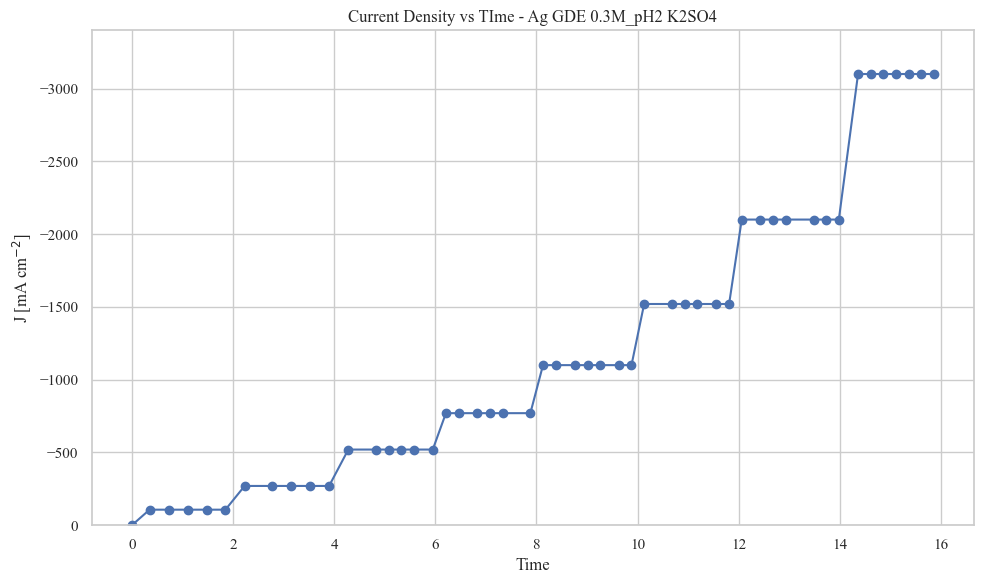

In [942]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH2 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

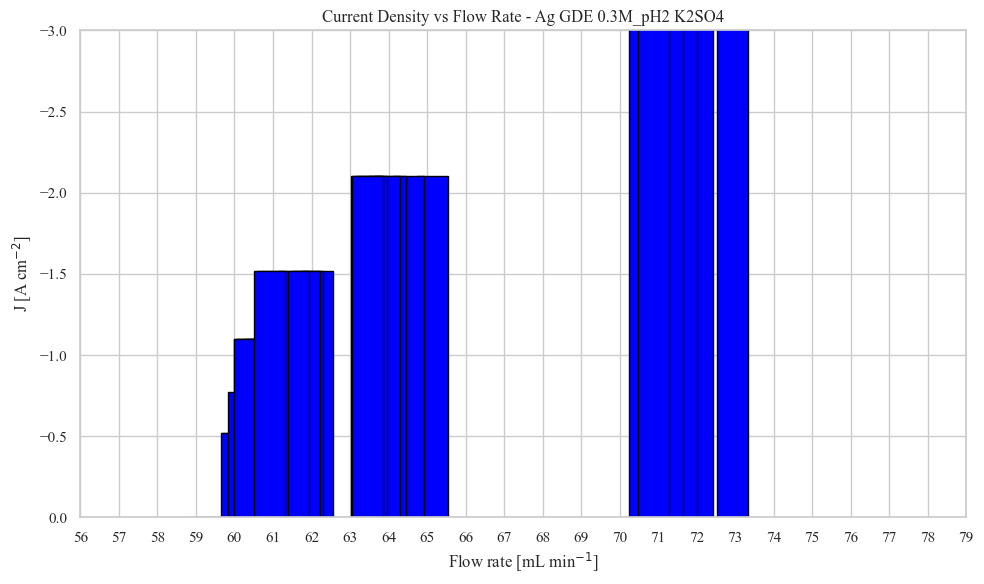

In [943]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH2 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


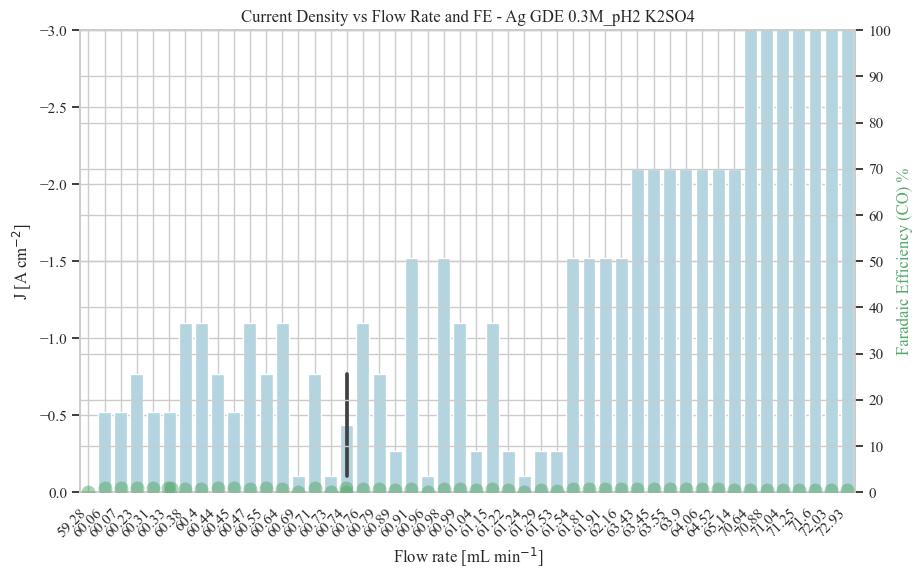

In [944]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH2 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.0)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240605_Ag_GDE_0_3M_pH2_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [945]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [946]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240605 - Ag60 GDE_0.3 M K2SO4_pH2

16-Aug-26  11:24 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
29-Jul-26  05:01 AM    <DIR>          .ipynb_checkpoints
29-Jul-26  11:29 AM           186,066 0p3M_pH2 K2SO4_20240607_1301_1min - Copy.xlsx
29-Jul-26  11:30 AM            66,274 0p3M_pH2 K2SO4_20240607_1301_1min.xlsx
07-Jun-24  03:01 PM            21,844 0p3M_pH2 K2SO4_20240607_1301_5min.xlsx
07-Jun-24  03:01 PM           670,811 0p3M_pH2 K2SO4_20240607_1301_Line_1.csv
25-Jul-25  09:26 PM           903,635 20240605 - Ag60 GDE_0.3 M K2SO4_pH2.ipynb
29-Jul-26  05:53 AM           687,413 20240605 - Ag60 GDE_0.3 M K2SO4_pH2-CORRECTED - Copy.ipynb
16-Aug-26  11:24 PM           898,650 20240605 - Ag60 GDE_0.3 M K2SO4_pH2-CORRECTED.ipynb
17-Aug-26  12:04 AM               598 20240605_0.3 M K2SO4_pH2_Energy Consumption.csv
16-Aug-26

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


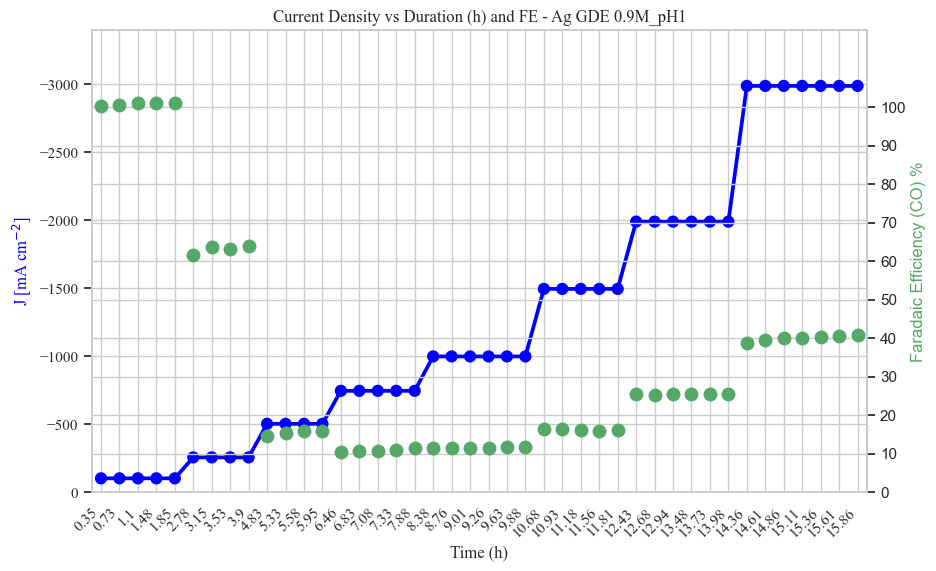

In [947]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(H2)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 120)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240605_Ag_GDE_0_3M_pH2_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initial step in each current

In [948]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.23].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.28].index)
rows = rows.drop(rows[rows['Duration / h'] == 5.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.21].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.13].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.13].index)
rows = rows.drop(rows[rows['Duration / h'] == 12.06].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,61.24,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:03:04,0.35,1.359127,...,61.24,0.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,105.813975
2,Ag60 GDE in PTFE holder,60,60.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:25:36,0.73,1.353346,...,60.96,0.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.315456
3,Ag60 GDE in PTFE holder,60,60.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 18:48:06,1.10,1.359606,...,60.74,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.567425
4,Ag60 GDE in PTFE holder,60,60.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 19:10:36,1.48,1.357080,...,60.69,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.277568
5,Ag60 GDE in PTFE holder,60,60.73,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.101,2024-06-05 19:33:07,1.85,1.358233,...,60.73,1.0,-101.0,0.107,0.101,59.106192,58.04932,59.542814,59.190691,102.288388
7,Ag60 GDE in PTFE holder,60,61.29,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 20:28:40,2.78,2.091754,...,61.29,2.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,101.107907
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 20:51:11,3.15,2.157189,...,61.22,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.324793
9,Ag60 GDE in PTFE holder,60,61.04,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 21:13:41,3.53,2.156862,...,61.04,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.918510
10,Ag60 GDE in PTFE holder,60,60.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-05 21:36:13,3.90,2.184025,...,60.89,3.0,-255.0,0.270,0.255,59.08553,58.365478,60.037825,59.058643,100.218399
11,Ag60 GDE in PTFE holder,60,60.33,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.502,2024-06-05 23:39:17,5.95,1.073454,...,60.33,5.0,-502.0,0.520,0.502,59.216587,58.050626,59.832855,59.342186,98.550541


## Current Density vs FE(CO)_ mean and std

### Stacked bar plot

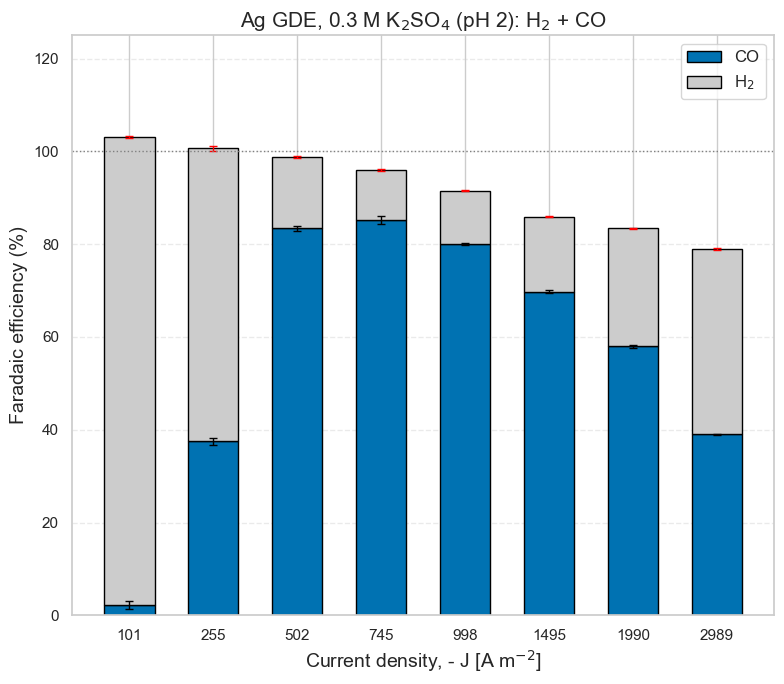

In [949]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

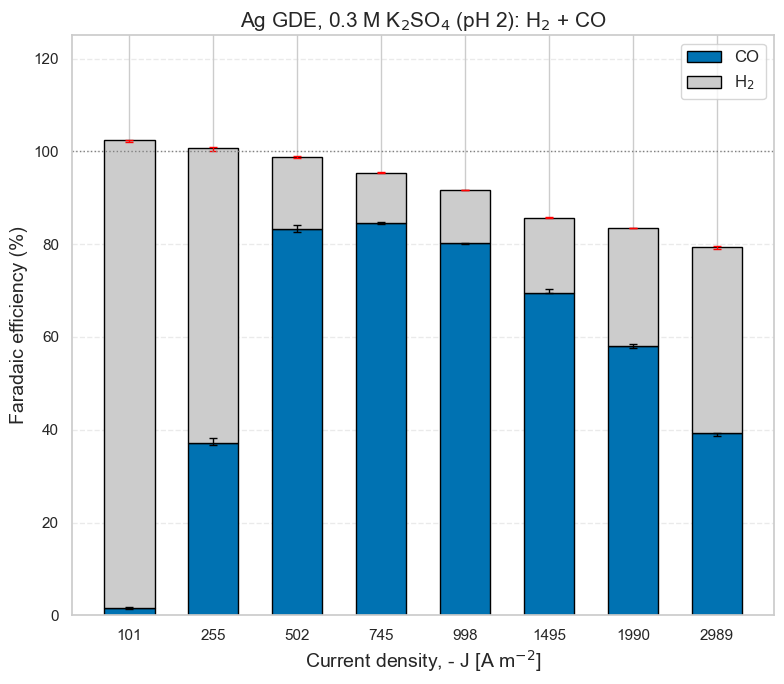

In [950]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [951]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [952]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,100.774116,2.278447,100.974354,1.498354,0.149917,0.816407,0.335225,1.825542,100.565348,...,0.013332,5,0.409006,0.001371,0.185692,0.251753,0.027068,0.251969,0–2,101
1,250,63.116205,37.526197,63.399407,37.222245,0.514393,0.712085,1.028786,1.424170,62.847223,...,0.021020,4,0.552184,0.268982,0.592439,0.896392,0.323457,0.344208,2–4,255
2,500,15.408186,83.374395,15.579700,83.304137,0.283102,0.454543,0.566204,0.909087,15.195934,...,0.010224,4,0.383766,0.212253,0.654734,0.724992,0.070132,0.311903,4–6,502
3,750,10.829449,85.131237,10.726265,84.627391,0.206662,0.878742,0.462110,1.964927,10.640422,...,0.010431,5,0.085843,0.200068,0.372362,0.123775,0.581981,0.701308,6–8,745
4,1000,11.491113,80.015263,11.438882,80.166775,0.055277,0.184411,0.135400,0.451713,11.397791,...,0.014906,6,0.041090,0.129454,0.180758,0.122242,0.252027,0.058473,8–10,998
5,1500,16.172650,69.757297,16.158202,69.549658,0.093076,0.293439,0.208125,0.656148,15.998328,...,0.031435,5,0.159875,0.184166,0.038066,0.832927,0.222232,0.434321,10–12,1495
6,2000,25.387705,57.989735,25.400099,58.096821,0.037798,0.287294,0.092586,0.703725,25.364912,...,0.065070,6,0.035187,0.016202,0.396642,0.461466,0.523517,0.477668,12–14,1990
7,3000,39.980286,38.975627,40.023141,39.257877,0.261189,0.200161,0.691042,0.529577,39.713142,...,0.148410,7,0.309999,0.373286,0.505863,0.059570,0.934460,0.346960,14–16,2989


In [956]:
Res_Book
# Res_Book.to_csv('20240605_0.3M K2SO4_pH2.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,100.774116,2.278447,100.974354,1.498354,0.149917,0.816407,0.335225,1.825542,100.565348,...,0.013332,5,0.409006,0.001371,0.185692,0.251753,0.027068,0.251969,0–2,101
1,250,63.116205,37.526197,63.399407,37.222245,0.514393,0.712085,1.028786,1.424170,62.847223,...,0.021020,4,0.552184,0.268982,0.592439,0.896392,0.323457,0.344208,2–4,255
2,500,15.408186,83.374395,15.579700,83.304137,0.283102,0.454543,0.566204,0.909087,15.195934,...,0.010224,4,0.383766,0.212253,0.654734,0.724992,0.070132,0.311903,4–6,502
3,750,10.829449,85.131237,10.726265,84.627391,0.206662,0.878742,0.462110,1.964927,10.640422,...,0.010431,5,0.085843,0.200068,0.372362,0.123775,0.581981,0.701308,6–8,745
4,1000,11.491113,80.015263,11.438882,80.166775,0.055277,0.184411,0.135400,0.451713,11.397791,...,0.014906,6,0.041090,0.129454,0.180758,0.122242,0.252027,0.058473,8–10,998
5,1500,16.172650,69.757297,16.158202,69.549658,0.093076,0.293439,0.208125,0.656148,15.998328,...,0.031435,5,0.159875,0.184166,0.038066,0.832927,0.222232,0.434321,10–12,1495
6,2000,25.387705,57.989735,25.400099,58.096821,0.037798,0.287294,0.092586,0.703725,25.364912,...,0.065070,6,0.035187,0.016202,0.396642,0.461466,0.523517,0.477668,12–14,1990
7,3000,39.980286,38.975627,40.023141,39.257877,0.261189,0.200161,0.691042,0.529577,39.713142,...,0.148410,7,0.309999,0.373286,0.505863,0.059570,0.934460,0.346960,14–16,2989


## Mean and StD of FE(CO) through time

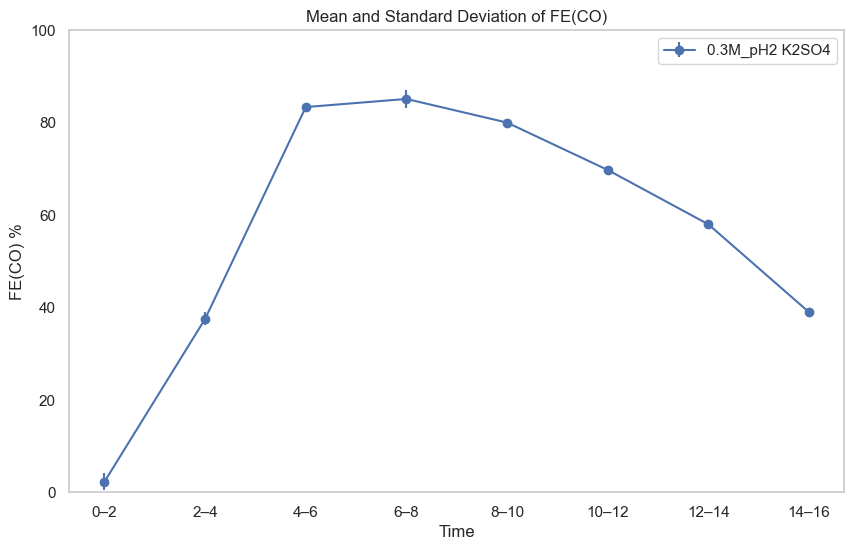

In [957]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M_pH2 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240605_0.3M_pH2_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

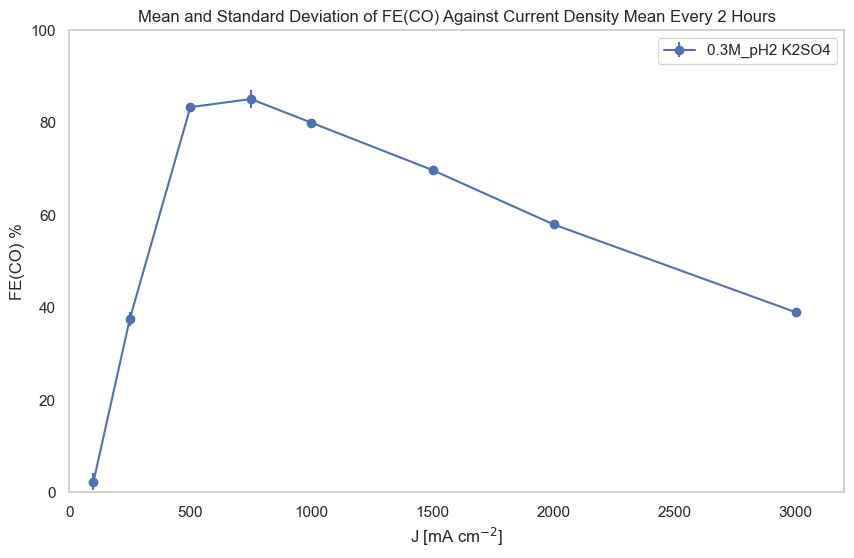

In [897]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M_pH2 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [mA cm$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240605_0.3M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()